In [111]:
# ... existing code ...
# Read the binary file
with open('mmapped_impl_test.bin', 'rb') as f:
    # Reading the file produces a bytes object.
    # Converting it to a list creates an array of integers (0s and 1s).
    data_array = list(f.read())

# Verify the data
print(f"Read {len(data_array)} bytes")
print(f"First 10 values: {data_array[:10]}")

Read 343067 bytes
First 10 values: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [118]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [253]:

def observe_slice(start, end):
    slice_to_observe = data_array[start:end]
    plt.plot([i * 20 / 1000.0 for i in range(0, len(slice_to_observe))], slice_to_observe)
    plt.xlabel('Approximate Time (ms)')


In [254]:
starts = []
ends = []

start_index = 0
last_one = 0
i = 0
while start_index < len(data_array):
    while start_index < len(data_array) and data_array[start_index] != 1:
        start_index += 1

    if start_index == len(data_array):
        break
    starts.append(start_index)
    last_one = start_index
    for i in range(start_index, len(data_array)):
        if data_array[i] == 1:
            last_one = i

        if i - last_one > 3500:
            ends.append(last_one)
            break
    start_index = i + 1



In [255]:
len(starts), len(ends)

(4, 4)

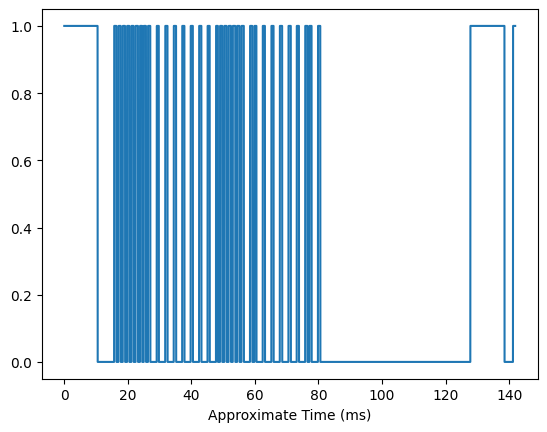

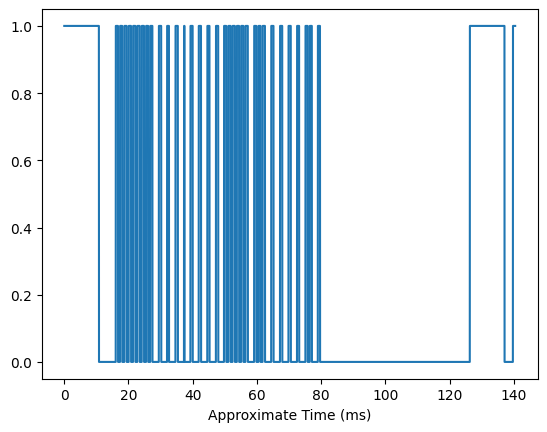

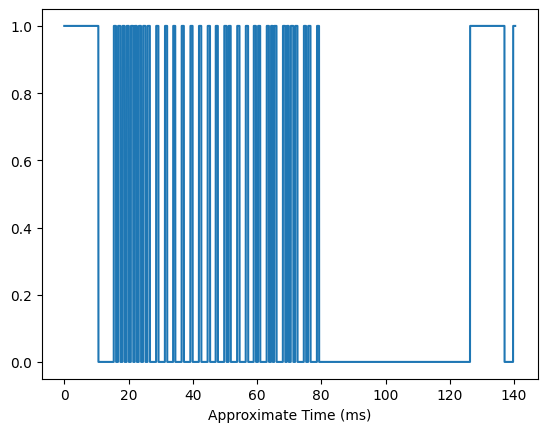

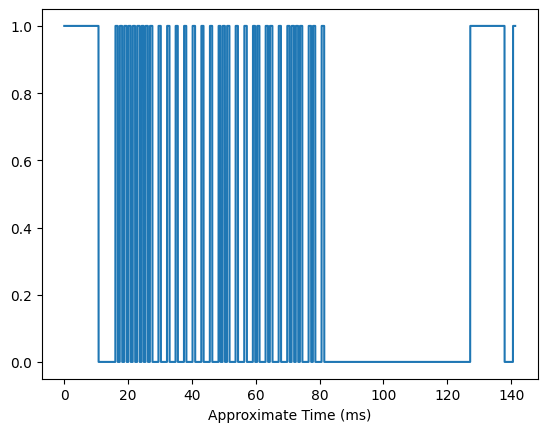

In [256]:
for i in range(len(starts)):
    observe_slice(starts[i], ends[i])
    plt.show()

In [59]:
pulses = []

for i in range(0, len(starts), 1):
    last = 0
    count = 0
    for d in range(starts[i], ends[i]):
        if last == 0 and data_array[d] == 1:
            count += 1
        last = data_array[d]
    pulses.append(count)

NameError: name 'starts' is not defined

In [258]:
pulses

[36, 36, 36, 36]

In [60]:
with open('signals.bin', 'rb') as f:
    # Reading the file produces a bytes object.
    # Converting it to a list creates an array of integers (0s and 1s).
    signal_array = f.read()


In [61]:
total_signals = int.from_bytes(signal_array[:8], byteorder="big", signed=True)
total_signals

34

In [62]:
import struct

In [75]:
pulse_length, = struct.unpack('>Q', signal_array[:8])
vals = struct.unpack('>' + ''.join(['Q' for i in range(pulse_length * 2)]), signal_array[8:8 + 16 * pulse_length])

In [76]:
[(vals[i], vals[i + 1]) for i in range(0, len(vals), 2)]

[(9117, 4486),
 (577, 542),
 (590, 532),
 (574, 522),
 (606, 538),
 (592, 538),
 (574, 538),
 (605, 522),
 (604, 538),
 (576, 1668),
 (592, 1661),
 (588, 1677),
 (572, 1675),
 (608, 1643),
 (607, 1661),
 (589, 1664),
 (605, 1645),
 (488, 522),
 (605, 538),
 (568, 538),
 (597, 538),
 (587, 538),
 (571, 544),
 (607, 1662),
 (572, 538),
 (598, 1680),
 (572, 1669),
 (609, 1644),
 (592, 1677),
 (589, 1663),
 (605, 1642),
 (614, 521),
 (605, 1651),
 (592, 40145)]

In [103]:
class Signal:
    def __init__(self, high, low):
        self.high = high
        self.low = low
    def __str__(self):
        return f"Signal(high={self.high}us, low={self.low}us)"
    def __repr__(self):
        return str(self)


In [104]:
i = 0
raw_signals = []
while i < len(signal_array):
    pulse_length, = struct.unpack('>Q', signal_array[i:i +8])
    i = i + 8
    data = struct.unpack('>' + ''.join(['Q' for i in range(pulse_length * 2)]), signal_array[i:i + 8 * pulse_length * 2])
    raw_signals.append(list(data))
    i = i + 8 * pulse_length * 2

In [105]:
signals = [[Signal(s[i], s[i + 1]) for i in range(0, len(s), 2)] for s in raw_signals]

<BarContainer object of 34 artists>

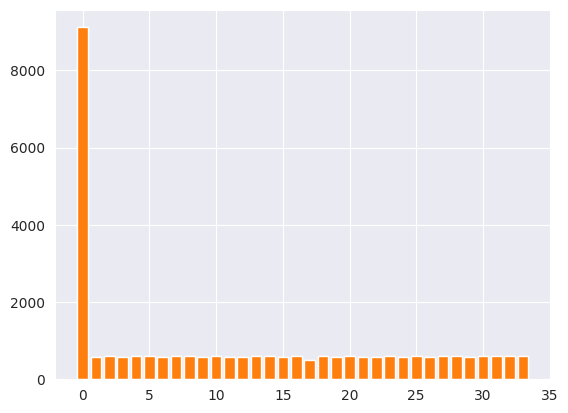

In [117]:
plt.bar([i for i in range(len(signals[0]))], [s.high for s in signals[0]])
plt.bar([i for i in range(len(signals[1]))], [s.high for s in signals[0]])

In [133]:
series = []
for i in range(len(signals)):
    for j in range(len(signals[i])):
        s = signals[i][j]
        series.append(pd.Series({"Pulse Set Id": i, "Pulse Index": j, "High Duration": s.high, "Low Duration": s.low }))
df  = pd.DataFrame(columns=["Pulse Set Id", "Pulse Index", "High Duration", "Low Duration"], data=series)

In [134]:
df


,Pulse Set Id,Pulse Index,High Duration,Low Duration
0,0,0,9117,4486
1,0,1,577,542
2,0,2,590,532
3,0,3,574,522
4,0,4,606,538
...,...,...,...,...
5997,176,29,607,1673
5998,176,30,574,1667
5999,176,31,626,1617
6000,176,32,607,1780


<Axes: xlabel='Pulse Index', ylabel='High Duration'>

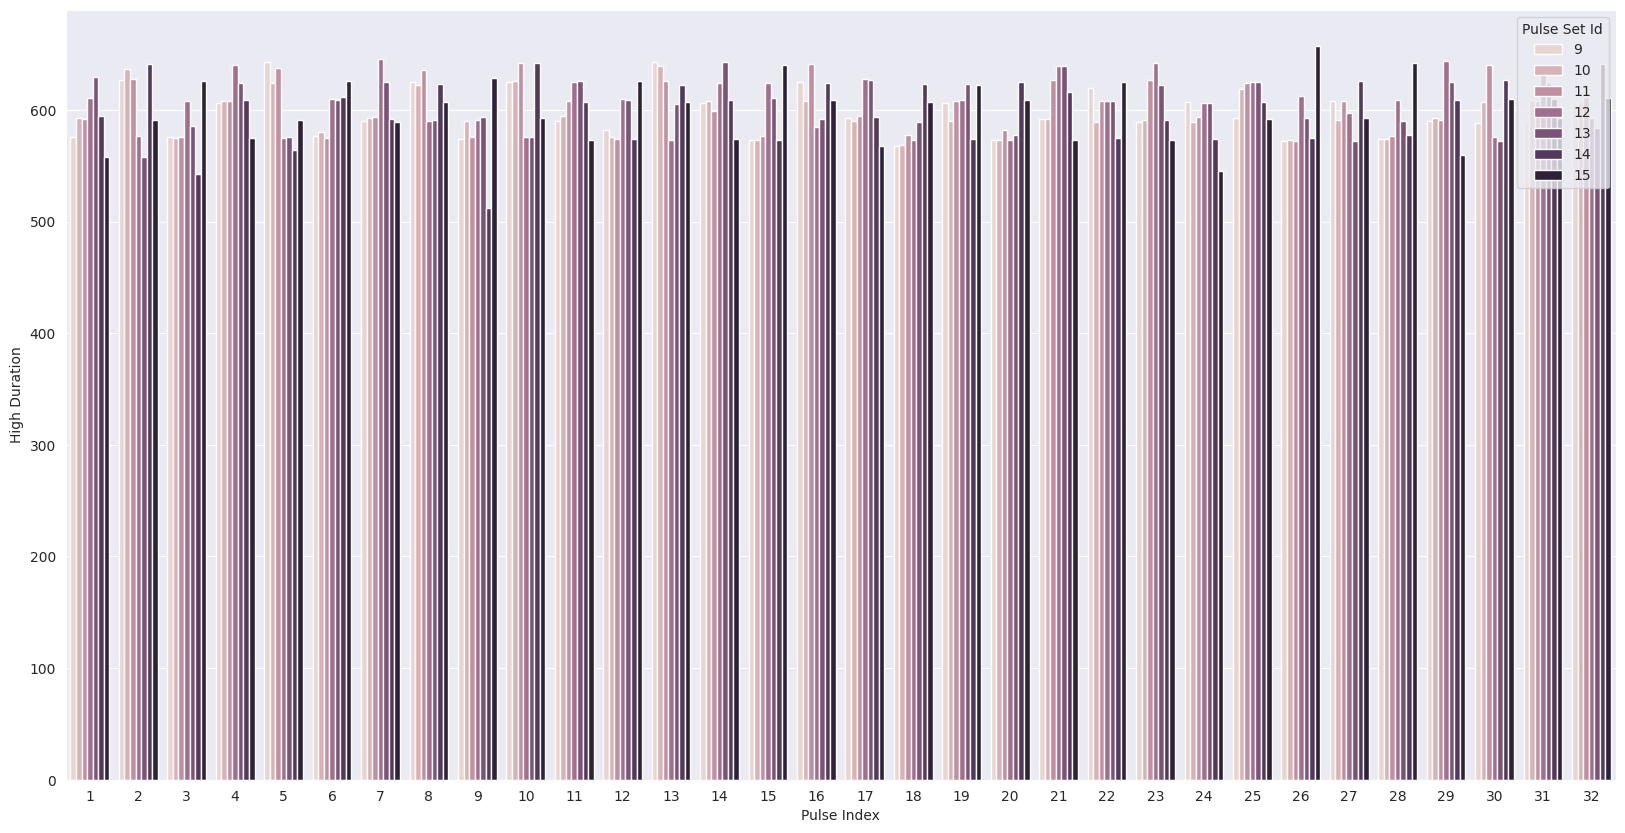

In [152]:
plt.figure(figsize=(20, 10))
sns.barplot(df[df["Pulse Set Id"].apply(lambda x: x in [9, 10, 11, 12, 13, 14, 15]) & df["Pulse Index"].apply(lambda x: x != 0 and x <= 32)], x="Pulse Index", y="High Duration", hue="Pulse Set Id")

<Axes: xlabel='Pulse Index', ylabel='Low Duration'>

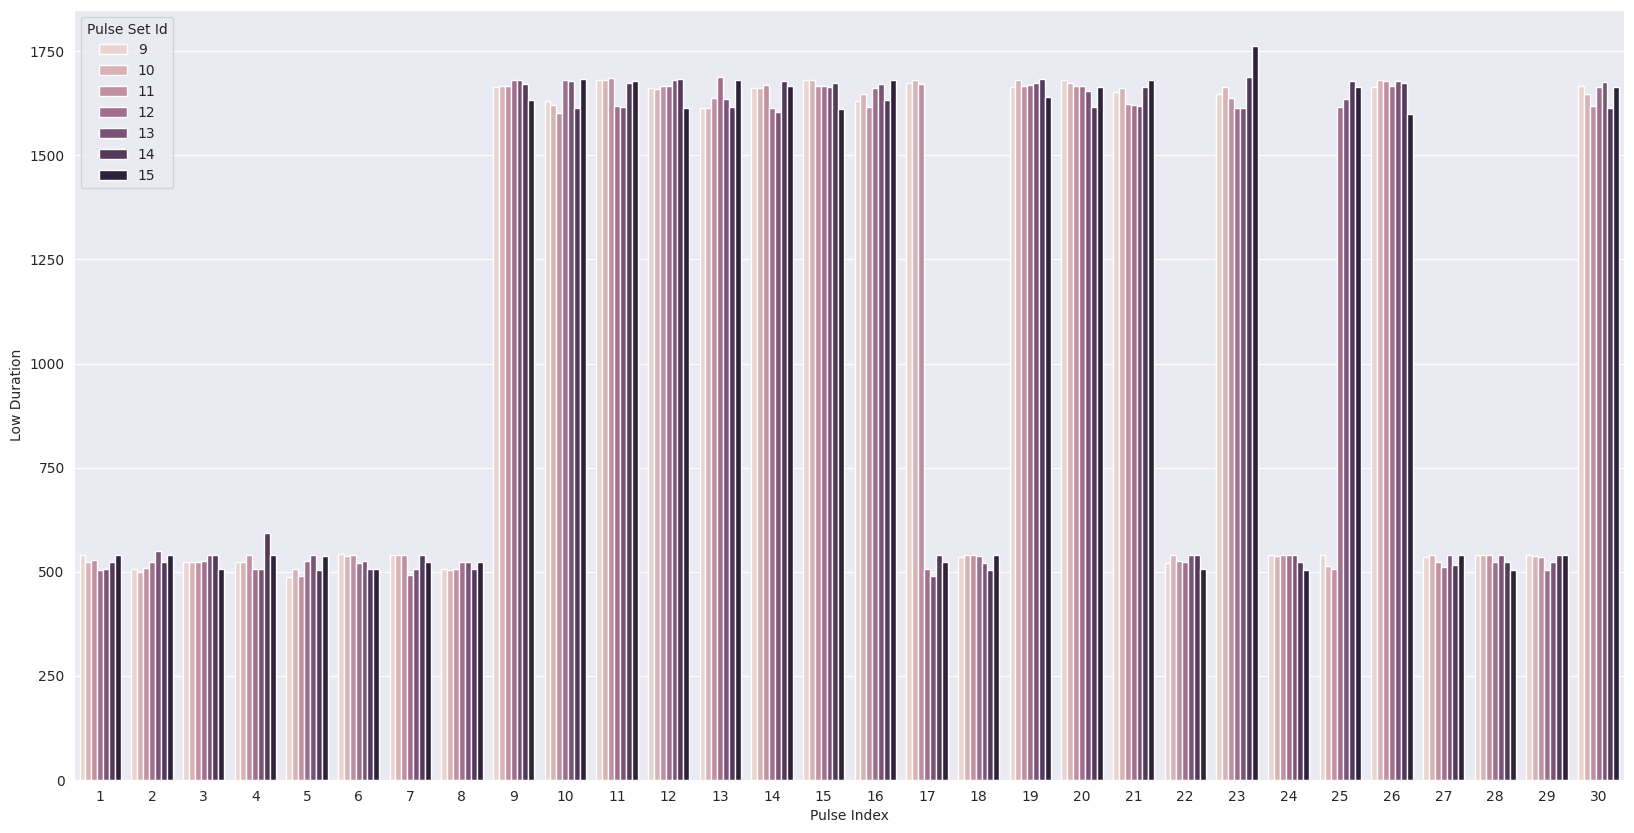

In [153]:
plt.figure(figsize=(20, 10))
sns.barplot(df[df["Pulse Set Id"].apply(lambda x: x in [9, 10, 11, 12, 13, 14, 15]) & df["Pulse Index"].apply(lambda x: x != 0 and x <= 30)], x="Pulse Index", y="Low Duration", hue="Pulse Set Id")